# Seasonality Study

In [1]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
#
from Calculations_Functions import proportions_from_filename, metrics_table
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
#filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added.zarr'
#filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/RESTART_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added_restart_365_days_no_release_1_year.zarr'
#
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_1.nc'
filename2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_year_2.nc'
#filename = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_1_2_years.nc'

In [3]:
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
with xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep]) as data1, \
     xr.open_dataset(filename2, drop_variables=[v for v in xr.open_dataset(filename2).variables if v not in vars_to_keep]) as data2:
    idx_JFM = int((90 * 86400) / 900)
    idx_AMJ = int((181 * 86400) / 900)
    idx_JAS = int((273 * 86400) / 900)
    idx_OND = int((365 * 86400) / 900)
    # Year 1
    data_winter_y1= data1.isel(trajectory=slice(0, idx_JFM), obs = slice(0, 90*8))
    data_spring_y1 = data1.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(90*8, 181*8))
    data_summer_y1 = data1.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(181*8, 273*8))
    data_fall_y1 = data1.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(273*8, 365*8))
    #
    # Year 2
    data_winter_y2 = data2.isel(trajectory=slice(0, idx_JFM), obs = slice(0, 90*8))
    data_spring_y2 = data2.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(90*8, 181*8))
    data_summe_y2 = data2.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(181*8, 273*8))
    data_fall_y2 = data2.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(273*8, 365*8)) 

In [3]:
# 1. Helper function to extract ONLY flattened, valid seasonal points
def get_season_1d(ds, target_months):
    # Flatten arrays directly
    status = ds['status'].values.flatten()
    months = ds['time'].dt.month.values.flatten()
    
    # Create mask for valid water points AND the target season
    valid_mask = (status > 0) & (status < 4) & np.isin(months, target_months)
    
    # Return only data that passes the mask to save memory
    return {
        'lon': ds['lon'].values.flatten()[valid_mask],
        'lat': ds['lat'].values.flatten()[valid_mask],
        'z': ds['z'].values.flatten()[valid_mask],
        'status': status[valid_mask]
    }

# 2. Helper function to combine Year 1 and Year 2 mathematically
def build_combined_dataset(dict1, dict2):
    combined_dict = {}
    for var in ['lon', 'lat', 'z', 'status']:
        # Simulates 2-year release: (Year 1) + (Year 2) + (Year 1 again)
        combined_dict[var] = (['points'], np.concatenate([dict1[var], dict2[var], dict1[var]]))
    return xr.Dataset(combined_dict)

vars_to_keep = ['lon', 'lat', 'z', 'time', 'status']

with xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep]) as data1, \
     xr.open_dataset(filename2, drop_variables=[v for v in xr.open_dataset(filename2).variables if v not in vars_to_keep]) as data2:
    
    # Trim the overlapping restart point from Year 2 (obs=0)
    data2_trimmed = data2.isel(obs=slice(1, None))
    
    # 3. Extract points for each season directly from datasets
    print("Extracting Winter...")
    w1 = get_season_1d(data1, [1, 2, 3])
    w2 = get_season_1d(data2_trimmed, [1, 2, 3])
    
    print("Extracting Spring...")
    sp1 = get_season_1d(data1, [4, 5, 6])
    sp2 = get_season_1d(data2_trimmed, [4, 5, 6])
    
    print("Extracting Summer...")
    su1 = get_season_1d(data1, [7, 8, 9])
    su2 = get_season_1d(data2_trimmed, [7, 8, 9])
    
    print("Extracting Fall...")
    f1 = get_season_1d(data1, [10, 11, 12])
    f2 = get_season_1d(data2_trimmed, [10, 11, 12])
    
    # 4. Build the final 1D datasets
    print("Building final datasets...")
    data_winter = build_combined_dataset(w1, w2)
    data_spring = build_combined_dataset(sp1, sp2)
    data_summer = build_combined_dataset(su1, su2)
    data_fall   = build_combined_dataset(f1, f2)

print("Done! You can now run create_robust_swath().")

# Example usage with your function:
# swath_matrix_winter, z_bins = create_robust_swath(data_winter, thalweg, mask, d_km)

Extracting Winter...
Extracting Spring...
Extracting Summer...
Extracting Fall...
Building final datasets...
Done! You can now run create_robust_swath().


# Seasonal Concentration Maps

Options:
- Map the final snapshot of the last day of each season while releasing to see where these are going within the same season,
- Map the whole second year seasons with no release but full particle count.
- Map a yearly snapchot of what happens when release in winter to winter, spring to spring, summer to summer and fall to fall.


Some other ideas:
- IF timeseries and maps, we can separate the simulations with seasonal decomposition and do an EOF analysis to get potentially a relation between spatial and temopral patterns :D

In [4]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [5]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [6]:
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)

In [7]:
def particles_amount_map(lons, lats, mask=mask, num_lon=100, num_lat=100):
    # Define bin edges
    lon_edges = np.linspace(mask['nav_lon'].min(), mask['nav_lon'].max(), num_lon + 1)
    lat_edges = np.linspace(mask['nav_lat'].min(), mask['nav_lat'].max(), num_lat + 1)

    # Use histogram2d instead of digitize + bincount
    counts, _, _ = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges]
    )

    # Convert to DataFrame, with bin centers as labels
    amount = pd.DataFrame(
        counts.T,  # transpose: rows=lat, cols=lon
        index=(lat_edges[:-1] + lat_edges[1:]) / 2,
        columns=(lon_edges[:-1] + lon_edges[1:]) / 2
    )

    return amount

In [8]:
def particles_amount_map_by_depth(lons, lats, depths, depth_bins, mask=mask, num_lon=100, num_lat=100):
    # Create lon-lat bin edges
    lon_edges = np.linspace(mask['nav_lon'].min(), mask['nav_lon'].max(), num_lon + 1)
    lat_edges = np.linspace(mask['nav_lat'].min(), mask['nav_lat'].max(), num_lat + 1)

    # Bin centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    results = {}
    raw_hist = {}
    grid_indices = {}  # to store ii_sed and jj_sed

    for depth_min, depth_max in depth_bins:
        # Select particles in current depth range
        depth_mask = (depths >= depth_min) & (depths <= depth_max)
        lon_sel = lons[depth_mask]
        lat_sel = lats[depth_mask]

        if len(lon_sel) > 0:
            counts, xedges, yedges = np.histogram2d(
                lon_sel, lat_sel,
                bins=[lon_edges, lat_edges]
            )
        else:
            counts = np.zeros((num_lon, num_lat))
            xedges, yedges = lon_edges, lat_edges

        # DataFrame (lat as rows, lon as cols)
        label = f"{depth_min}-{depth_max} m"
        results[label] = pd.DataFrame(
            counts.T,  # shape: (num_lat, num_lon)
            index=lat_centers,
            columns=lon_centers
        )

        # Raw hist outputs
        raw_hist[label] = (counts, xedges, yedges)

        # Build ii_sed and jj_sed on **bin centers**, same shape as counts.T
        Xedges, Yedges = np.meshgrid(lon_centers, lat_centers)  # shape: (num_lat, num_lon)
        ii_sed = np.zeros_like(Xedges, dtype=int)
        jj_sed = np.zeros_like(Xedges, dtype=int)

        for i in range(Xedges.shape[0]):
            for j in range(Xedges.shape[1]):
                jj, ii = finder2(Yedges[i, j], Xedges[i, j], mask)
                ii_sed[i, j] = ii
                jj_sed[i, j] = jj

        grid_indices[label] = (ii_sed, jj_sed)

    return results, raw_hist, grid_indices


In [10]:
#lon_sed = data_combined.where(data_combined['status'] > 10)['lon'].values.ravel()        
#lat_sed = data_combined.where(data_combined['status'] > 10)['lat'].values.ravel()
#depth_sed = data_combined.where(data_combined['status'] > 10)['z'].values.ravel()
#########
#lon_wat = data_combined.where((data_combined['status'] > 0) & (data_combined['status'] < 4))['lon'].values.ravel()
#lat_wat = data_combined.where((data_combined['status'] > 0) & (data_combined['status'] < 4))['lat'].values.ravel()
#depth_wat = data_combined.where((data_combined['status'] > 0) & (data_combined['status'] < 4))['z'].values.ravel()

# Year 1

In [ ]:
# Pull the underlying arrays once
status = data1['status'].values
lon = data1['lon'].values
lat = data1['lat'].values
z = data1['z'].values

# Create boolean indices
idx_sed = status > 10
idx_wat = (status > 0) & (status < 4)

# Extract values directly
lon_sed, lat_sed, depth_sed = lon[idx_sed], lat[idx_sed], z[idx_sed]
lon_wat, lat_wat, depth_wat = lon[idx_wat], lat[idx_wat], z[idx_wat]

Depth ranges

In [12]:
depths_bins = [(0,50), (50,200), (200,400)]

In [13]:
labels = ['0-50 m', '50-200 m', '200-400 m']

In [ ]:
amount_sediment, _, grid_ij_sediment = particles_amount_map_by_depth(lons=lon_sed, lats=lat_sed, depths = depth_sed, depth_bins = depths_bins)
amount_water,  _, grid_ij_water = particles_amount_map_by_depth(lons=lon_wat, lats=lat_wat, depths = depth_wat, depth_bins = depths_bins)
total_amount,  _, grid_ij = particles_amount_map_by_depth(lons=data1['lon'].values.flatten(), lats=data1['lat'].values.flatten(), depths = data1['z'].values.flatten(), depth_bins = depths_bins)
#
#total_amount_sediment = particles_amount_map(lons=lon_sed, lats=lat_sed)
#total_amount_water = particles_amount_map(lons=lon_wat, lats=lat_wat)
total_amount_depth = particles_amount_map(lons=data1['lon'].values.flatten(), lats=data1['lat'].values.flatten())

In [15]:
from matplotlib.colors import ListedColormap, BoundaryNorm
# Colormap for mask
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)

/tmp/ipykernel_492708/1741202077.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  example = ax.pcolormesh(grid_ij_water["0-50 m"][0],grid_ij_water["0-50 m"][1], amount_water["0-50 m"], cmap = 'Purples', norm=colors.LogNorm(vmin=total_amount_depth.min().min() + 1e-2, vmax=total_amount_depth.max().max()))


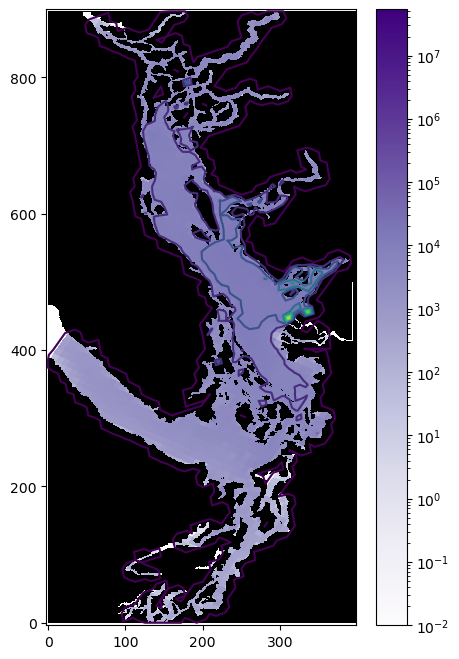

In [16]:
fig, ax = plt.subplots(figsize = (5,8))
example = ax.pcolormesh(grid_ij_water["0-50 m"][0],grid_ij_water["0-50 m"][1], amount_water["0-50 m"], cmap = 'Purples', norm=colors.LogNorm(vmin=total_amount_depth.min().min() + 1e-2, vmax=total_amount_depth.max().max()))
plt.colorbar(example)
ax.contour(grid_ij_water["0-50 m"][0],grid_ij_water["0-50 m"][1], amount_water["0-50 m"])
ax.pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)


Seasons contours

Winter

In [ ]:
# 1. Extract the raw numpy arrays once to avoid Xarray overhead
status_arr = data_winter_last['status'].values
lon_arr = data_winter_last['lon'].values
lat_arr = data_winter_last['lat'].values
z_arr = data_winter_last['z'].values

# 2. Create the masks (boolean arrays)
# These will be the same shape as your data but only take 1 bit per element
mask_sed = status_arr > 10
mask_wat = (status_arr > 0) & (status_arr < 4)

# 3. Apply masks directly to the arrays
# This automatically flattens the result into a 1D array of only the "True" values
lon_sed_winter = lon_arr[mask_sed]
lat_sed_winter = lat_arr[mask_sed]
depth_sed_winter = z_arr[mask_sed]

lon_wat_winter = lon_arr[mask_wat]
lat_wat_winter = lat_arr[mask_wat]
depth_wat_winter = z_arr[mask_wat]

# 4. Pass the cleaned arrays to your function
water_amount_winter, _, ij_water_winter = particles_amount_map_by_depth(
    lons=lon_wat_winter, 
    lats=lat_wat_winter, 
    depths=depth_wat_winter, 
    depth_bins=depths_bins
)

sediment_amount_winter, _, ij_sediment_winter = particles_amount_map_by_depth(
    lons=lon_sed_winter, 
    lats=lat_sed_winter, 
    depths=depth_sed_winter, 
    depth_bins=depths_bins
)

Spring

In [18]:
# 1. Extract raw numpy arrays to minimize overhead
status_spring = data_spring_last['status'].values
lon_spring = data_spring_last['lon'].values
lat_spring = data_spring_last['lat'].values
z_spring = data_spring_last['z'].values

# 2. Define the boolean masks
mask_sed_spring = status_spring > 10
mask_wat_spring = (status_spring > 0) & (status_spring < 4)

# 3. Use boolean indexing to extract and flatten in one step
# These only create small arrays containing relevant data points
lon_sed_spring = lon_spring[mask_sed_spring]
lat_sed_spring = lat_spring[mask_sed_spring]
depth_sed_spring = z_spring[mask_sed_spring]

lon_wat_spring = lon_spring[mask_wat_spring]
lat_wat_spring = lat_spring[mask_wat_spring]
depth_wat_spring = z_spring[mask_wat_spring]

# 4. Process through your mapping function
water_amount_spring, _, ij_water_spring = particles_amount_map_by_depth(
    lons=lon_wat_spring, 
    lats=lat_wat_spring, 
    depths=depth_wat_spring, 
    depth_bins=depths_bins
)

sediment_amount_spring, _, ij_sediment_spring = particles_amount_map_by_depth(
    lons=lon_sed_spring, 
    lats=lat_sed_spring, 
    depths=depth_sed_spring, 
    depth_bins=depths_bins
)

Summer

In [19]:
# 1. Access the underlying numpy arrays once
status_summer = data_summer_last['status'].values
lon_summer = data_summer_last['lon'].values
lat_summer = data_summer_last['lat'].values
z_summer = data_summer_last['z'].values

# 2. Define the masks for sediment and water
mask_sed_summer = status_summer > 10
mask_wat_summer = (status_summer > 0) & (status_summer < 4)

# 3. Apply masks (this extracts and flattens simultaneously)
lon_sed_summer = lon_summer[mask_sed_summer]
lat_sed_summer = lat_summer[mask_sed_summer]
depth_sed_summer = z_summer[mask_sed_summer]

lon_wat_summer = lon_summer[mask_wat_summer]
lat_wat_summer = lat_summer[mask_wat_summer]
depth_wat_summer = z_summer[mask_wat_summer]

# 4. Map the amounts by depth
water_amount_summer, _, ij_water_summer = particles_amount_map_by_depth(
    lons=lon_wat_summer, 
    lats=lat_wat_summer, 
    depths=depth_wat_summer, 
    depth_bins=depths_bins
)

sediment_amount_summer, _, ij_sediment_summer = particles_amount_map_by_depth(
    lons=lon_sed_summer, 
    lats=lat_sed_summer, 
    depths=depth_sed_summer, 
    depth_bins=depths_bins
)

Fall

In [20]:
# 1. Pull the data into numpy arrays once to avoid multiple Xarray passes
status_fall = data_fall_last['status'].values
lon_fall = data_fall_last['lon'].values
lat_fall = data_fall_last['lat'].values
z_fall = data_fall_last['z'].values

# 2. Create the masks for sediment and water
mask_sed_fall = status_fall > 10
mask_wat_fall = (status_fall > 0) & (status_fall < 4)

# 3. Use boolean indexing to extract and flatten simultaneously
lon_sed_fall = lon_fall[mask_sed_fall]
lat_sed_fall = lat_fall[mask_sed_fall]
depth_sed_fall = z_fall[mask_sed_fall]

lon_wat_fall = lon_fall[mask_wat_fall]
lat_wat_fall = lat_fall[mask_wat_fall]
depth_wat_fall = z_fall[mask_wat_fall]

# 4. Final calculations for the fall season
water_amount_fall, _, ij_water_fall = particles_amount_map_by_depth(
    lons=lon_wat_fall, 
    lats=lat_wat_fall, 
    depths=depth_wat_fall, 
    depth_bins=depths_bins
)

sediment_amount_fall, _, ij_sediment_fall = particles_amount_map_by_depth(
    lons=lon_sed_fall, 
    lats=lat_sed_fall, 
    depths=depth_sed_fall, 
    depth_bins=depths_bins
)

In [21]:
Q1 = 10
Q2 = 25
Q3 = 50
Q4 = 75
#
d_water_surface1 = amount_water['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_water_surface1 = np.nanpercentile(d_water_surface1, q = Q1)
#
d_sediment_surface1 = amount_sediment['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_surface1 = np.nanpercentile(d_sediment_surface1, q = Q1)
#
d_water_surface2 = amount_water['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_water_surface2 = np.nanpercentile(d_water_surface2, q = Q2)
#
d_sediment_surface2 = amount_sediment['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_surface2 = np.nanpercentile(d_sediment_surface2, q = Q2)
#
d_water_surface3 = amount_water['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_water_surface3 = np.nanpercentile(d_water_surface3, q = Q3)
#
d_sediment_surface3 = amount_sediment['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_surface3 = np.nanpercentile(d_sediment_surface3, q = Q3)
#
d_water_surface4 = amount_water['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_water_surface4 = np.nanpercentile(d_water_surface4, q = Q4)
#
d_sediment_surface4 = amount_sediment['0-50 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_surface4 = np.nanpercentile(d_sediment_surface4, q = Q4)
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #  
d_water_intermediate1 = amount_water['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_water_intermediate1 = np.nanpercentile(d_water_intermediate1, q = Q1)
#
d_sediment_intermediate1 = amount_sediment['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_intermediate1 = np.nanpercentile(d_sediment_intermediate1, q = Q1)
#
d_water_intermediate2 = amount_water['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_water_intermediate2 = np.nanpercentile(d_water_intermediate2, q = Q2)
#
d_sediment_intermediate2 = amount_sediment['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_intermediate2 = np.nanpercentile(d_sediment_intermediate2, q = Q2)
#
d_water_intermediate3 = amount_water['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_water_intermediate3 = np.nanpercentile(d_water_intermediate3, q = Q3)
#
d_sediment_intermediate3 = amount_sediment['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_intermediate3 = np.nanpercentile(d_sediment_intermediate3, q = Q3)
#
d_water_intermediate4 = amount_water['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_water_intermediate4 = np.nanpercentile(d_water_intermediate4, q = Q4)
#
d_sediment_intermediate4 = amount_sediment['50-200 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_intermediate4 = np.nanpercentile(d_sediment_intermediate4, q = Q4)
# # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # # #  
d_water_bottom1 = amount_water['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_water_bottom1 = np.nanpercentile(d_water_bottom1, q = Q1)
#
d_sediment_bottom1 = amount_sediment['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_bottom1 = np.nanpercentile(d_sediment_bottom1, q = Q1)
#
d_water_bottom2 = amount_water['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_water_bottom2 = np.nanpercentile(d_water_bottom2, q = Q2)
#
d_sediment_bottom2 = amount_sediment['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_bottom2 = np.nanpercentile(d_sediment_bottom2, q = Q2)
#
d_water_bottom3 = amount_water['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_water_bottom3 = np.nanpercentile(d_water_bottom3, q = Q3)
#
d_sediment_bottom3 = amount_sediment['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_bottom3 = np.nanpercentile(d_sediment_bottom3, q = Q3)
#
d_water_bottom4 = amount_water['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_water_bottom4 = np.nanpercentile(d_water_bottom4, q = Q4)
#
d_sediment_bottom4 = amount_sediment['200-400 m'].replace(0.0, np.nan).values.ravel()
TT_sediment_bottom4 = np.nanpercentile(d_sediment_bottom4, q = Q4)

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

colors_3 = ["#ffffff", "#b0714d", "#38c033", "#8f309d", "#999999"]



In [23]:
grids_water = [ij_water_winter, ij_water_spring, ij_water_summer, ij_water_fall]

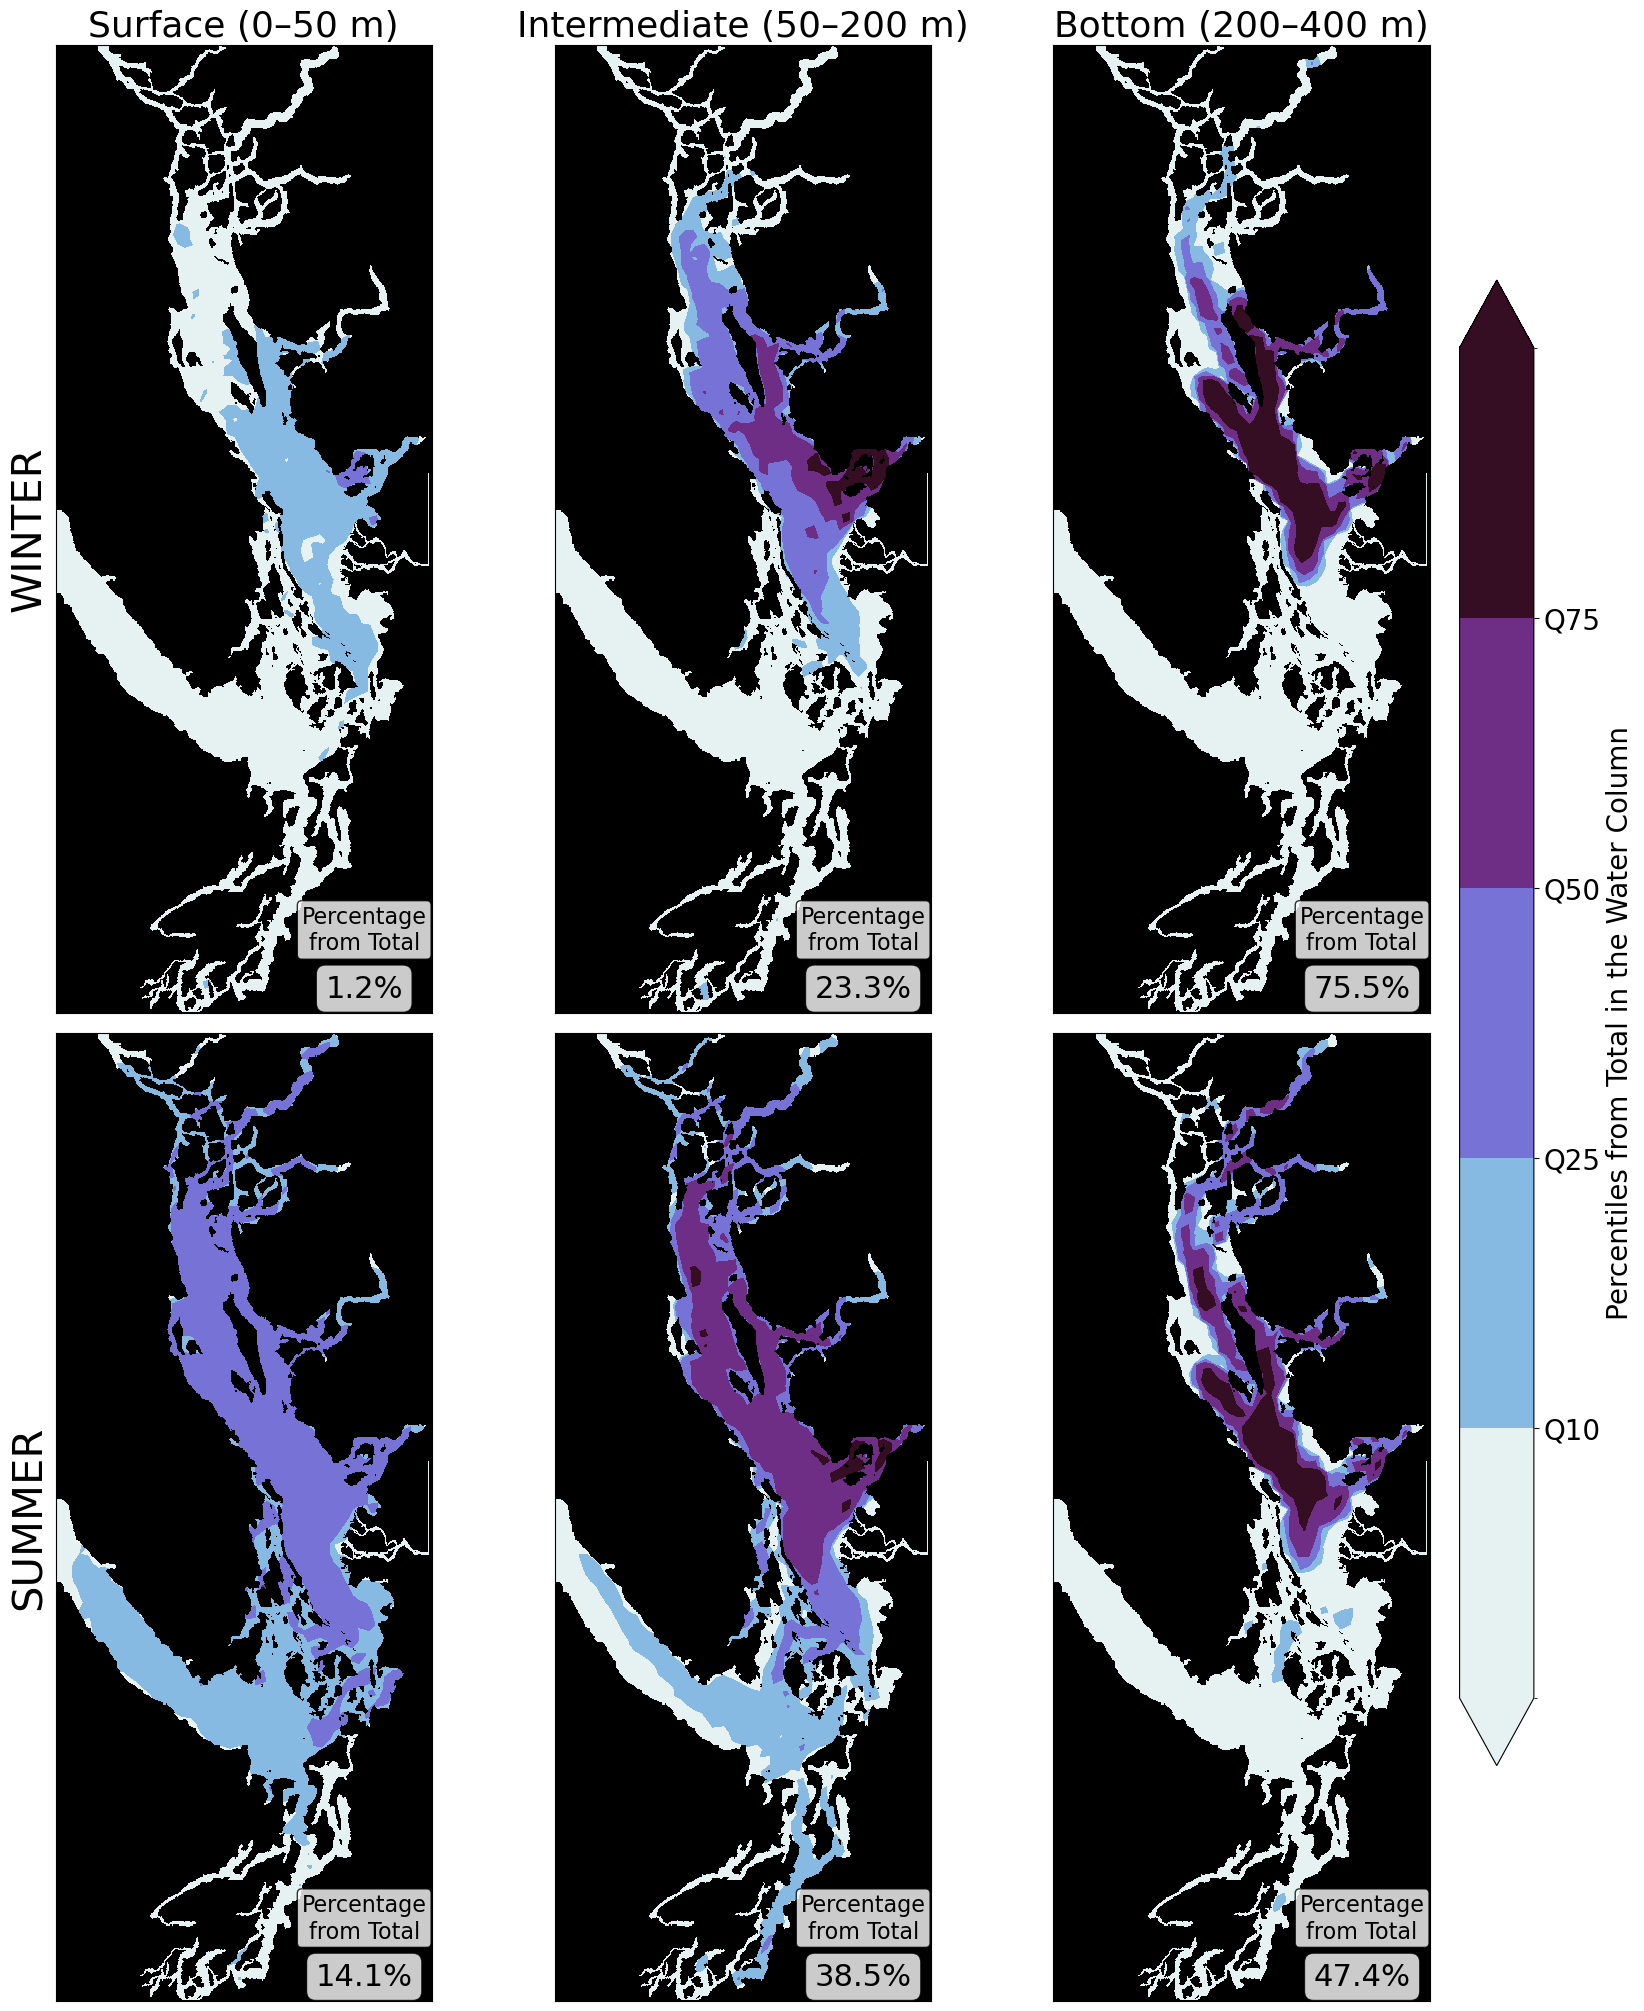

In [26]:
from matplotlib.colors import BoundaryNorm
plt.rcParams.update({'font.size': 20})

# percentiles
PCTS = [10, 25, 50, 75]
layers = ["0-50 m", "50-200 m", "200-400 m"]
seasons = ["WINTER", "SUMMER"]
water_amounts = {"WINTER": water_amount_winter, "SUMMER": water_amount_summer}

# ====== 1. Compute ALL values for color bounds ======
all_vals = []
for layer in layers:
    arr = amount_water[layer].replace(0.0, np.nan).values.ravel()
    arr = arr[~np.isnan(arr)]
    if arr.size > 0:
        all_vals.append(arr)

all_vals = np.concatenate(all_vals)
global_Qs = np.nanpercentile(all_vals, PCTS)
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)
bounds = [vmin, global_Qs[0], global_Qs[1], global_Qs[2], global_Qs[3], vmax]

# ====== 2. Compute fractions per layer per season ======
# total for each season
totals = {
    season: np.nansum([water_amounts[season][layer] for layer in layers])
    for season in seasons
}

# fraction (%) per season and layer
fractions = {
    season: {
        layer: 100 * np.nansum(water_amounts[season][layer]) / totals[season]
        for layer in layers
    }
    for season in seasons
}

# ====== 3. Plot ======
fig, ax = plt.subplots(2, 3, figsize=(17, 20), constrained_layout=True)
cmap_3 = cm.dense
norm = BoundaryNorm(bounds, cmap_3.N)

titles = ["Surface (0–50 m)", "Intermediate (50–200 m)", "Bottom (200–400 m)"]

for r, season in enumerate(seasons):
    for c, layer in enumerate(layers):

        data = water_amounts[season][layer]

        cf = ax[r, c].contourf(
            grids_water[c][layer][0], grids_water[c][layer][1],
            data,
            levels=bounds,
            cmap=cmap_3,
            norm=norm,
            extend="both"
        )

        ax[r, c].pcolormesh(X, Y, mask['tmask'][0][0], cmap=cmap)

        # Titles and labels
        if r == 0:
            ax[r, c].set_title(titles[c], fontsize=26)
        if c == 0:
            ax[r, c].set_ylabel(season, fontsize=30)
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        ax[r, c].set_aspect(1.14)

        # ====== 4. Add annotation box with layer percentage ======
        perc = fractions[season][layer]

        # Title above the box
        ax[r, c].text(
            0.82, 0.06,                       # slightly above the box
            "Percentage\nfrom Total",
            transform=ax[r, c].transAxes,
            ha="center",
            va="bottom",
            fontsize=16,
            color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8)
        )

        # Percentage box
        ax[r, c].text(
            0.82, 0.01,
            f"{perc:.1f}%",
            transform=ax[r, c].transAxes,
            ha="center",
            va="bottom",
            fontsize=22,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
        )

# ====== 5. Colorbar shared ======
cbar = fig.colorbar(cf, ax=ax.ravel().tolist(),
                    orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_ticks(global_Qs)
cbar.set_ticklabels(["Q10", "Q25", "Q50", "Q75"])
cbar.set_label('Percentiles from Total in the Water Column')

plt.show()


-----

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cmocean # Assuming cm.dense comes from here

# --- 1. CONFIGURATION ---
depth_bins = [(0, 50), (50, 200), (200, 400)]
layers = ['0-50 m', '50-200 m', '200-400 m']

# Put your raw Xarray datasets into a dictionary
raw_datasets = {
    "WINTER": data_winter,
    "SPRING": data_spring,
    "SUMMER": data_summer,
    "FALL": data_fall
}

# Dictionaries to hold our processed results
water_amounts = {}
water_grids = {}

# --- 2. AUTOMATED PROCESSING LOOP ---
print("Processing spatial maps...")
for season, ds in raw_datasets.items():
    status_arr = ds['status'].values
    lon_arr = ds['lon'].values
    lat_arr = ds['lat'].values
    z_arr = ds['z'].values

    # Mask for water particles
    mask_wat = (status_arr > 0) & (status_arr < 4)
    
    # Process through your function
    amounts, _, grids = particles_amount_map_by_depth(
        lons=lon_arr[mask_wat], 
        lats=lat_arr[mask_wat], 
        depths=z_arr[mask_wat], 
        depth_bins=depth_bins,
        mask=mask # assuming 'mask' is loaded in your environment
    )
    
    water_amounts[season] = amounts
    water_grids[season] = grids

print("Data processing complete!")

Processing spatial maps...


: 

In [ ]:
def plot_seasonal_heatmaps(amounts_dict, grids_dict, mask, seasons_to_plot, layers_to_plot):
    plt.rcParams.update({'font.size': 20})
    
    # ====== 1. Compute Global Percentiles for Color Bounds ======
    all_vals = []
    for season in seasons_to_plot:
        for layer in layers_to_plot:
            arr = amounts_dict[season][layer].replace(0.0, np.nan).values.ravel()
            arr = arr[~np.isnan(arr)]
            if arr.size > 0:
                all_vals.append(arr)

    all_vals = np.concatenate(all_vals)
    PCTS = [10, 25, 50, 75, 90]
    global_Qs = np.nanpercentile(all_vals, PCTS)
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    
    bounds = [vmin, global_Qs[0], global_Qs[1], global_Qs[2], global_Qs[3], global_Qs[4], vmax]
    
    # ====== 2. Compute Layer Fractions per Season ======
    totals = {
        season: np.nansum([amounts_dict[season][layer] for layer in layers_to_plot])
        for season in seasons_to_plot
    }
    
    fractions = {
        season: {
            layer: 100 * np.nansum(amounts_dict[season][layer]) / totals[season]
            for layer in layers_to_plot
        }
        for season in seasons_to_plot
    }

    # ====== 3. Plot Setup ======
    rows = len(seasons_to_plot)
    cols = len(layers_to_plot)
    fig, axes = plt.subplots(rows, cols, figsize=(10, 6 * rows), constrained_layout=True)
    
    # Ensure axes is always a 2D array even if plotting 1 season
    if rows == 1: axes = np.expand_dims(axes, axis=0)
    
    cmap_3 = cmocean.cm.amp # Replace with your specific colormap if different
    norm = BoundaryNorm(bounds, cmap_3.N)
    
    # Prepare land mask background coordinates (assuming X, Y are 2D meshgrids of your model domain)
    X, Y = np.meshgrid(np.arange(mask['tmask'].shape[3]), np.arange(mask['tmask'].shape[2]))

    # ====== 4. Plotting Loop ======
    for r, season in enumerate(seasons_to_plot):
        for c, layer in enumerate(layers_to_plot):
            ax = axes[r, c]
            data = amounts_dict[season][layer]
            
            # The grids dictionary structure: grids[season][layer][0] is ii_sed, [1] is jj_sed
            grid_x = grids_dict[season][layer][0]
            grid_y = grids_dict[season][layer][1]

            # Heatmap
            cf = ax.contourf(
                grid_x, grid_y, data,
                levels=bounds, cmap=cmap_3, norm=norm, extend="both"
            )

            # Land mask overlay
            ax.pcolormesh(X, Y, mask['tmask'][0][0], cmap='gray_r', alpha=0.3)

            # Labels and Aesthetics
            if r == 0:
                # Give nice titles based on layer
                title_map = {"0-50 m": "Surface (0–50 m)", "50-200 m": "Intermediate (50–200 m)", "200-400 m": "Bottom (200–400 m)"}
                ax.set_title(title_map.get(layer, layer), fontsize=14)
            if c == 0:
                ax.set_ylabel(season, fontsize=30)
                
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect(1.14)

            # ====== 5. Annotations ======
            perc = fractions[season][layer]
            
            # Title above box
            ax.text(
                0.5, 0.01, '% from Total: ' + f"{perc:.1f}%", transform=ax.transAxes,
                ha="center", va="bottom", fontsize=14, color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.8)
            )
            # Value box
            #ax.text(
            #    0.81, 0.01, f"{perc:.1f}%", transform=ax.transAxes,
            #    ha="center", va="bottom", fontsize=16,
            #    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
            #)

    # ====== 6. Global Colorbar ======
    cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.05, pad=0.02)
    cbar.set_ticks(global_Qs)
    cbar.set_ticklabels(["Q10", "Q25", "Q50", "Q75", "Q90"])
    cbar.set_label('Percentiles from Total in the Water Column')
    plt.show()
    plt.tight_layout()

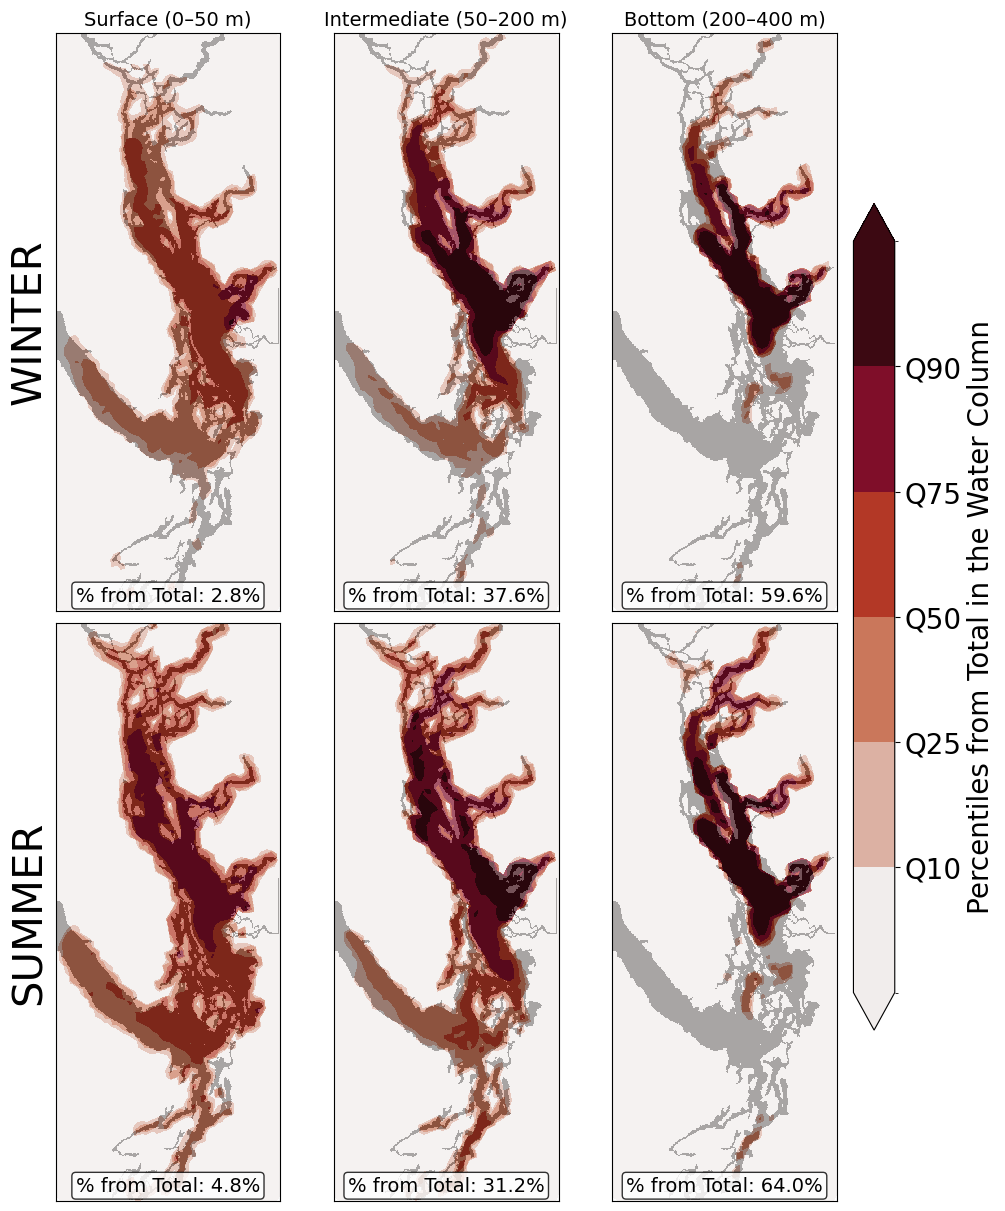

<Figure size 640x480 with 0 Axes>

In [ ]:
seasons_to_plot = ["WINTER", "SUMMER"]
plot_seasonal_heatmaps(water_amounts, water_grids, mask, seasons_to_plot, layers)

-----

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.transforms import Affine2D
plt.rcParams.update({'font.size': 18})
# Colormap for mask
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)

# Seasons dictionary
seasons = {
    "WINTER": "blue",
    "SPRING": "green",
    "SUMMER": "orange",
    "FALL": "red"
}

# Depth layers
layers = ["0-50 m", "50-200 m", "200-400 m"]

# Percentile thresholds (25 and 50 for each depth layer)
TT1 = [TT_water_surface1, TT_water_intermediate1, TT_water_bottom1]
TT2 = [TT_water_surface2, TT_water_intermediate2, TT_water_bottom2]
TT3 = [TT_water_surface3, TT_water_intermediate3, TT_water_bottom3]
#
grids_water = [ij_water_winter, ij_water_spring, ij_water_summer, ij_water_fall]

# Create figure
fig, ax = plt.subplots(4, 3, figsize=(20, 25), constrained_layout=True)


for row, (season, col) in enumerate(seasons.items()):
    for col_idx, layer in enumerate(layers):

        # Main plot with rotation
        c = ax[row, col_idx].pcolormesh(grid_ij_water[layer][0],grid_ij_water[layer][1],
                                        amount_water[layer], cmap = cm.thermal, 
                                        norm=colors.LogNorm(vmin=total_amount_depth.min().min() + 1e-2, vmax=1e5))

        # Contour with rotation
        cs = ax[row, col_idx].contour(grids_water[col_idx][layer][0],grids_water[col_idx][layer][1],
                                      eval(f"water_amount_{season.lower()}")[layer],
                                      levels=[TT1[col_idx], TT2[col_idx], TT3[col_idx]],
                                      colors=['tab:brown', 'g', 'm'],
                                      linestyles=["-", "-", "-"],
                                      linewidths=1.5)

        # Mask overlay with rotation
        ax[row, col_idx].pcolormesh(X,Y,
                                    mask['tmask'][0][0], cmap=cmap)

        # Titles (top row only)
        if row == 0:
            titles = ["Surface (0–50 m)", "Intermediate (50–200 m)", "Bottom (200–400 m)"]
            ax[row, col_idx].set_title(titles[col_idx])

        # Y labels (left col only)
        if col_idx == 0:
            ax[row, col_idx].set_ylabel(season, fontsize=30)

        # Remove ticks
        ax[row, col_idx].set_xticks([])
        ax[row, col_idx].set_yticks([])

        # Add vertical colorbar
        cb = fig.colorbar(c, ax=ax[row, col_idx], orientation="vertical", fraction=0.05, pad=0.02)
        cb.set_label("Amount in Water Column")

        # Add percentile marks on the colorbar
        cb.ax.hlines(TT1[col_idx], *cb.ax.get_xlim(), colors="tab:brown", linestyles="-", linewidth=2)
        cb.ax.hlines(TT2[col_idx], *cb.ax.get_xlim(), colors="g", linestyles="-", linewidth=2)
        cb.ax.hlines(TT3[col_idx], *cb.ax.get_xlim(), colors="m", linestyles="-", linewidth=2)

        cb.ax.text(0.0, TT1[col_idx] + TT1[col_idx] / 2, f"{Q1}th", va="center", ha="left", fontsize=7, color="black")
        cb.ax.text(0.0, TT2[col_idx] + TT2[col_idx] / 2, f"{Q2}th", va="center", ha="left", fontsize=7, color="black")
        cb.ax.text(0.0, TT3[col_idx] + TT3[col_idx] / 2, f"{Q3}th", va="center", ha="left", fontsize=7, color="black")

plt.show()
plt.tight_layout()


In [ ]:
# Percentile thresholds (25 and 50 for each depth layer)
TT1 = [TT_sediment_surface1, TT_sediment_intermediate1, TT_sediment_bottom1]
TT2 = [TT_sediment_surface2, TT_sediment_intermediate2, TT_sediment_bottom2]
TT3 = [TT_sediment_surface3, TT_sediment_intermediate3, TT_sediment_bottom3]
#
grids_sediment = [ij_sediment_winter, ij_sediment_spring, ij_sediment_summer, ij_sediment_fall]

# Create figure
fig, ax = plt.subplots(4, 3, figsize=(20, 20), constrained_layout=True)

# Define the 49° rotation
rotation = Affine2D().rotate_deg(-29)

for row, (season, col) in enumerate(seasons.items()):
    for col_idx, layer in enumerate(layers):

        # Main plot with rotation
        c = ax[row, col_idx].pcolormesh(grid_ij_sediment[layer][0],grid_ij_sediment[layer][1],
                                        amount_sediment[layer], cmap = 'Blues', 
                                        norm=colors.LogNorm(vmin=total_amount_depth.min().min() + 1e-2, vmax=total_amount_depth.max().max()))

        # Contour with rotation
        cs = ax[row, col_idx].contour(grids_sediment[col_idx][layer][0],grids_sediment[col_idx][layer][1],
                                      eval(f"sediment_amount_{season.lower()}")[layer],
                                      levels=[TT1[col_idx], TT2[col_idx], TT3[col_idx]],
                                      colors=['tab:brown', 'g', 'm'],
                                      linestyles=["-", "-", "-"],
                                      linewidths=1.5)

        # Mask overlay with rotation
        ax[row, col_idx].pcolormesh(X,Y,
                                    mask['tmask'][0][0], cmap=cmap)

        # Titles (top row only)
        if row == 0:
            titles = ["Surface (0–50 m)", "Intermediate (50–200 m)", "Bottom (200–400 m)"]
            ax[row, col_idx].set_title(titles[col_idx])

        # Y labels (left col only)
        if col_idx == 0:
            ax[row, col_idx].set_ylabel(season, fontsize=30)

        # Remove ticks
        ax[row, col_idx].set_xticks([])
        ax[row, col_idx].set_yticks([])

        # Add vertical colorbar
        cb = fig.colorbar(c, ax=ax[row, col_idx], orientation="vertical", fraction=0.05, pad=0.02)
        cb.set_label("Amount in Sediment")

        # Add percentile marks on the colorbar
        cb.ax.hlines(TT1[col_idx], *cb.ax.get_xlim(), colors="tab:brown", linestyles="-", linewidth=2)
        cb.ax.hlines(TT2[col_idx], *cb.ax.get_xlim(), colors="g", linestyles="-", linewidth=2)
        cb.ax.hlines(TT3[col_idx], *cb.ax.get_xlim(), colors="m", linestyles="-", linewidth=2)

        cb.ax.text(0.0, TT1[col_idx] + TT1[col_idx] / 2, f"{Q1}th", va="center", ha="left", fontsize=7, color="black")
        cb.ax.text(0.0, TT2[col_idx] + TT2[col_idx] / 2, f"{Q2}th", va="center", ha="left", fontsize=7, color="black")
        cb.ax.text(0.0, TT3[col_idx] + TT3[col_idx] / 2, f"{Q3}th", va="center", ha="left", fontsize=7, color="black")

plt.show()
plt.tight_layout()


Comments from Susan:

- Do the same exact plots but:
    - Look at what is happening after 9 months of released, so -> Winter to Fall (9 months), Spring to Winter (9months), Summer to Spring (9 months) and Fall to Summer (9 months). This would help to answer the question of: Does it matter more wheen in time are we looking? Or more it matters when the particles where released?